# Training Model Klasifikasi Prioritas Penerima Bantuan Sosial

**Mata Kuliah:** Konsep Perancangan dan Pengembangan Perangkat Lunak
**Studi Kasus:** Sistem berbasis AI untuk menentukan prioritas penerima bantuan sosial skala RT/lingkungan

## Tujuan Notebook
Notebook ini berisi proses training model **Random Forest Classifier** yang **diselaraskan dengan modul backend `app/ai_model.py`** pada repository tim. Pada arsitektur sistem ini:

- Mesin utama penentu skor prioritas adalah **MCDM (Multi-Criteria Decision Making)** berbobot manual yang transparan (lihat `WEIGHTS` di `ai_model.py`) — inilah yang menghasilkan skor 0-100 dan kategori kelayakan yang dipakai sistem.
- Model **Random Forest** pada notebook ini dilatih menggunakan dataset yang labelnya berasal dari hasil perhitungan MCDM tersebut, sehingga berfungsi sebagai **cross-check / validasi tambahan** terhadap hasil MCDM, bukan sebagai mesin keputusan utama.

Notebook ini menghasilkan model RF yang **identik secara fungsi** dengan yang dibuat oleh `train_and_save()` di `ai_model.py`, namun disusun lebih lengkap dengan EDA dan evaluasi mendalam untuk keperluan akademik (laporan/sidang).

## Fitur yang Digunakan (5 fitur, sesuai `ai_model.py`)
| Fitur | Tipe | Nilai yang Mungkin |
|---|---|---|
| `pendapatan_bulanan` | Numerik | Rp 0 - Rp 7.000.000 |
| `jumlah_tanggungan` | Numerik | 0 - 8 orang |
| `kondisi_tempat_tinggal` | Ordinal | Rusak Berat, Rusak Sedang, Layak |
| `kepemilikan_aset` | Ordinal | Rendah, Sedang, Tinggi |
| `indikator_tambahan` | Nominal | Disabilitas, Sakit Kronis, Lansia, Anak Putus Sekolah, Tidak Ada |

Target: `kategori_kelayakan` (Kurang Layak / Layak / Sangat Layak), hasil pemetaan dari `skor_prioritas` dengan ambang batas: skor > 75 → Sangat Layak, 50-75 → Layak, < 50 → Kurang Layak.

## Alur Notebook
1. Import Library
2. Load Dataset
3. Data Preprocessing
4. Exploratory Data Analysis (EDA)
5. Split Data (Train-Test)
6. Training Model (Random Forest)
7. Evaluasi Model
8. Feature Importance (Explainability)
9. Simpan Model untuk Integrasi ke Web App (kompatibel dengan `app/ai_model.py`)


## 1. Import Library

In [1]:
# --- Manipulasi data ---
import pandas as pd
import numpy as np

# --- Visualisasi ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing ---
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# --- Split data & evaluasi ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# --- Model ---
from sklearn.ensemble import RandomForestClassifier

# --- Menyimpan model ---
import joblib

# Pengaturan tampilan plot
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Untuk hasil yang konsisten setiap kali notebook dijalankan ulang
# (sama dengan seed=42 yang dipakai app/ai_model.py)
RANDOM_STATE = 42

print('Semua library berhasil diimpor.')

Semua library berhasil diimpor.


## 2. Load Dataset

Dataset yang digunakan adalah `dummy_dataset.csv`, yaitu dataset yang dihasilkan oleh fungsi `generate_dataset()` pada `app/ai_model.py`. Dataset ini berisi data warga sintetis yang sudah diberi label `kategori_kelayakan` berdasarkan perhitungan skor MCDM (ground-truth), sehingga konsisten dengan logika yang berjalan di backend.

> Jika file `dummy_dataset.csv` belum tersedia, jalankan `python -m app.ai_model` pada repository backend terlebih dahulu untuk membuatnya, lalu salin ke folder yang sama dengan notebook ini.

In [2]:
# Load dataset dari file CSV (separator default koma, sesuai output generate_dataset())
df = pd.read_csv('dummy_dataset.csv')

# Menampilkan ukuran dataset (jumlah baris, jumlah kolom)
print(f'Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom')

# Menampilkan 5 data teratas untuk gambaran awal
df.head()

Jumlah data: 600 baris, 7 kolom


,pendapatan_bulanan,jumlah_tanggungan,kondisi_tempat_tinggal,kepemilikan_aset,indikator_tambahan,skor_prioritas,kategori_kelayakan
0,5363900.0,1,Rusak Berat,Tinggi,Lansia,32.36,Kurang Layak
1,2054301.0,3,Rusak Berat,Tinggi,Disabilitas,60.69,Layak
2,5676566.0,8,Rusak Berat,Tinggi,Anak Putus Sekolah,48.50,Kurang Layak
3,266612.0,0,Rusak Berat,Rendah,Sakit Kronis,77.13,Sangat Layak
4,4239227.0,0,Layak,Rendah,Tidak Ada,23.33,Kurang Layak


In [3]:
# Informasi tipe data tiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pendapatan_bulanan      600 non-null    float64
 1   jumlah_tanggungan       600 non-null    int64  
 2   kondisi_tempat_tinggal  600 non-null    object 
 3   kepemilikan_aset        600 non-null    object 
 4   indikator_tambahan      600 non-null    object 
 5   skor_prioritas          600 non-null    float64
 6   kategori_kelayakan      600 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 32.9+ KB


In [4]:
# Statistik deskriptif untuk kolom numerik
df.describe()

,pendapatan_bulanan,jumlah_tanggungan,skor_prioritas
count,6.000000e+02,600.000000,600.000000
mean,3.449860e+06,4.251667,51.200667
std,2.010556e+06,2.599922,16.386738
min,1.418700e+04,0.000000,7.360000
25%,1.813634e+06,2.000000,40.287500
50%,3.446322e+06,4.000000,50.500000
75%,5.229843e+06,7.000000,63.792500
max,6.993524e+06,8.000000,94.720000


## 3. Data Preprocessing

Tahapan preprocessing yang dilakukan:
1. Mengecek *missing values*
2. Mengecek data duplikat
3. Menangani kolom `skor_prioritas` (ground-truth MCDM, berpotensi *data leakage*)
4. Encoding kolom kategorikal (ordinal & nominal) — **urutan kategori disamakan persis dengan `app/ai_model.py`**
5. Encoding label target

### 3.1 Mengecek Missing Values

In [5]:
# Mengecek jumlah missing value di setiap kolom
missing_values = df.isnull().sum()
print('Jumlah missing value per kolom:')
print(missing_values)

# Jika ada missing value, tangani dengan strategi berikut:
# - Kolom numerik     -> diisi dengan median (lebih tahan terhadap outlier dibanding mean)
# - Kolom kategorikal -> diisi dengan modus (nilai paling sering muncul)
if missing_values.sum() > 0:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])
    print('\nMissing value telah ditangani.')
else:
    print('\nTidak ditemukan missing value pada dataset.')

Jumlah missing value per kolom:
pendapatan_bulanan        0
jumlah_tanggungan         0
kondisi_tempat_tinggal    0
kepemilikan_aset          0
indikator_tambahan        0
skor_prioritas            0
kategori_kelayakan        0
dtype: int64

Tidak ditemukan missing value pada dataset.


### 3.2 Mengecek Data Duplikat

In [6]:
# Mengecek dan menghapus baris duplikat jika ada
jumlah_duplikat = df.duplicated().sum()
print(f'Jumlah baris duplikat: {jumlah_duplikat}')

if jumlah_duplikat > 0:
    df = df.drop_duplicates()
    print(f'Duplikat telah dihapus. Sisa data: {df.shape[0]} baris')
else:
    print('Tidak ada data duplikat.')

Jumlah baris duplikat: 0
Tidak ada data duplikat.


### 3.3 Menangani Kolom `skor_prioritas` (Data Leakage)

> **Catatan penting:** Kolom `skor_prioritas` adalah **ground-truth langsung** hasil perhitungan MCDM (`compute_priority()` di `ai_model.py`), dan kolom `kategori_kelayakan` (target kita) **diturunkan langsung** dari `skor_prioritas` lewat fungsi `kategori_dari_skor()`. Artinya hubungan keduanya bersifat deterministik (rumus matematis, bukan pola statistik).
>
> Jika `skor_prioritas` diikutsertakan sebagai fitur input (X), model tidak lagi "belajar" — ia hanya perlu menghafal aturan ambang batas (>75 / 50-75 / <50). Ini disebut **data leakage**, dan membuat model tidak merepresentasikan kemampuan generalisasi RF yang sesungguhnya terhadap fitur-fitur sosial-ekonomi mentah.
>
> Oleh karena itu, kolom `skor_prioritas` **dikeluarkan dari fitur (X)** dan hanya dipakai untuk EDA, sama seperti pendekatan `_encode_row()` pada `ai_model.py` yang juga tidak menyertakan `skor_prioritas` sebagai fitur RF.

In [7]:
# Kolom yang dipakai sebagai fitur (X) — PERSIS sama dengan urutan _encode_row() di app/ai_model.py
# 'skor_prioritas' SENGAJA tidak dimasukkan karena merupakan ground-truth MCDM (data leakage)
fitur_numerik = [
    'pendapatan_bulanan',
    'jumlah_tanggungan'
]

fitur_kategorikal_ordinal = [
    'kondisi_tempat_tinggal',  # Rusak Berat < Rusak Sedang < Layak
    'kepemilikan_aset'         # Rendah < Sedang < Tinggi
]

fitur_kategorikal_nominal = [
    'indikator_tambahan'       # Disabilitas, Sakit Kronis, Lansia, Anak Putus Sekolah, Tidak Ada
]

kolom_target = 'kategori_kelayakan'

print('Fitur numerik   :', fitur_numerik)
print('Fitur ordinal   :', fitur_kategorikal_ordinal)
print('Fitur nominal   :', fitur_kategorikal_nominal)
print('Kolom target    :', kolom_target)
print('Kolom dikecualikan : skor_prioritas (ground-truth MCDM, data leakage)')

Fitur numerik   : ['pendapatan_bulanan', 'jumlah_tanggungan']
Fitur ordinal   : ['kondisi_tempat_tinggal', 'kepemilikan_aset']
Fitur nominal   : ['indikator_tambahan']
Kolom target    : kategori_kelayakan
Kolom dikecualikan : skor_prioritas (ground-truth MCDM, data leakage)


### 3.4 Encoding Kolom Kategorikal

Urutan kategori ordinal disamakan **persis** dengan konstanta `KONDISI_RUMAH` dan `KEPEMILIKAN_ASET` pada `app/ai_model.py`, agar index hasil encoding identik dengan yang dipakai fungsi `_encode_row()` di backend:

```python
KONDISI_RUMAH = ("Rusak Berat", "Rusak Sedang", "Layak")
KEPEMILIKAN_ASET = ("Rendah", "Sedang", "Tinggi")
```

Kolom `indikator_tambahan` bersifat **nominal** (5 kategori tanpa urutan tingkat yang jelas secara linear), namun karena `ai_model.py` meng-encode-nya berdasarkan posisi index pada tuple `INDIKATOR_TAMBAHAN`, kita ikuti pendekatan yang sama agar model konsisten dengan backend:

```python
INDIKATOR_TAMBAHAN = ("Disabilitas", "Sakit Kronis", "Lansia", "Anak Putus Sekolah", "Tidak Ada")
```

In [8]:
# Salin dataframe agar data asli (df) tetap utuh untuk keperluan EDA
df_encoded = df.copy()

# --- Urutan kategori HARUS sama persis dengan app/ai_model.py ---
KONDISI_RUMAH = ('Rusak Berat', 'Rusak Sedang', 'Layak')
KEPEMILIKAN_ASET = ('Rendah', 'Sedang', 'Tinggi')
INDIKATOR_TAMBAHAN = ('Disabilitas', 'Sakit Kronis', 'Lansia', 'Anak Putus Sekolah', 'Tidak Ada')

# --- Encoding fitur ordinal sesuai urutan tingkatan logis ---
ordinal_encoder = OrdinalEncoder(categories=[
    list(KONDISI_RUMAH),
    list(KEPEMILIKAN_ASET)
])

df_encoded[fitur_kategorikal_ordinal] = ordinal_encoder.fit_transform(
    df_encoded[fitur_kategorikal_ordinal]
)

# --- Encoding fitur nominal 'indikator_tambahan' berdasarkan index tuple (sama seperti backend) ---
indikator_to_index = {nilai: idx for idx, nilai in enumerate(INDIKATOR_TAMBAHAN)}
df_encoded['indikator_tambahan'] = df_encoded['indikator_tambahan'].map(indikator_to_index)

print('Contoh data setelah encoding:')
df_encoded[fitur_kategorikal_ordinal + fitur_kategorikal_nominal].head()

Contoh data setelah encoding:


,kondisi_tempat_tinggal,kepemilikan_aset,indikator_tambahan
0,0.0,2.0,2
1,0.0,2.0,0
2,0.0,2.0,3
3,0.0,0.0,1
4,2.0,0.0,4


### 3.5 Encoding Label Target

Label target (`kategori_kelayakan`) di-encode menjadi angka menggunakan `LabelEncoder`. Mapping-nya dicatat agar mudah diinterpretasikan kembali saat evaluasi maupun saat dipakai di backend.

In [9]:
# Encoding label target
label_encoder = LabelEncoder()
df_encoded['kategori_kelayakan_encoded'] = label_encoder.fit_transform(df_encoded[kolom_target])

# Menampilkan mapping antara label asli dan label angka hasil encoding
mapping_label = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print('Mapping label target:')
for label, kode in mapping_label.items():
    print(f'  {label} -> {kode}')

Mapping label target:
  Kurang Layak -> 0
  Layak -> 1
  Sangat Layak -> 2


## 4. Exploratory Data Analysis (EDA)

Eksplorasi sederhana untuk memahami pola dan sebaran data sebelum training model.

### 4.1 Distribusi Kelas Target

Karena threshold MCDM (`skor > 75` untuk Sangat Layak) relatif ketat, distribusi kelas target diperkirakan **tidak seimbang** — perlu diperiksa secara eksplisit karena akan mempengaruhi strategi training (`class_weight`).

kategori_kelayakan
Kurang Layak    293
Layak           261
Sangat Layak     46
Name: count, dtype: int64

Proporsi (%):
kategori_kelayakan
Kurang Layak    48.83
Layak           43.50
Sangat Layak     7.67
Name: count, dtype: float64


C:\Users\shabrina\AppData\Local\Temp\ipykernel_48488\2444142580.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=kolom_target, order=distribusi_target.index, palette='viridis')


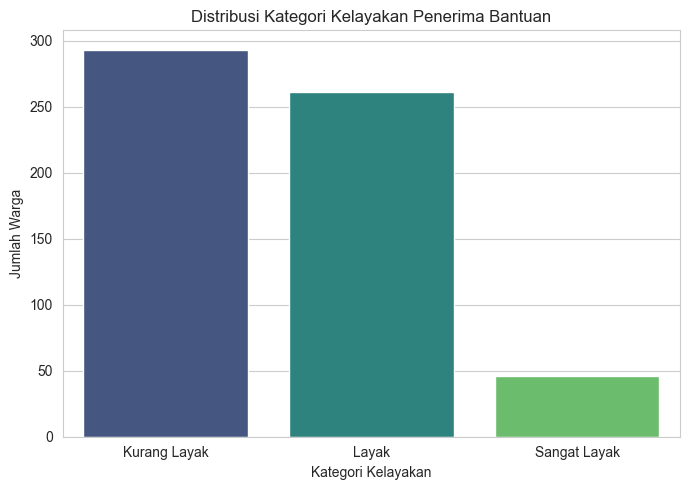

In [10]:
# Distribusi jumlah data per kategori kelayakan
distribusi_target = df[kolom_target].value_counts()
print(distribusi_target)
print()
print('Proporsi (%):')
print((distribusi_target / len(df) * 100).round(2))

# Visualisasi distribusi kelas target
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=kolom_target, order=distribusi_target.index, palette='viridis')
plt.title('Distribusi Kategori Kelayakan Penerima Bantuan')
plt.xlabel('Kategori Kelayakan')
plt.ylabel('Jumlah Warga')
plt.tight_layout()
plt.show()

### 4.2 Distribusi Fitur Numerik

Melihat sebaran nilai pendapatan bulanan dan jumlah tanggungan.

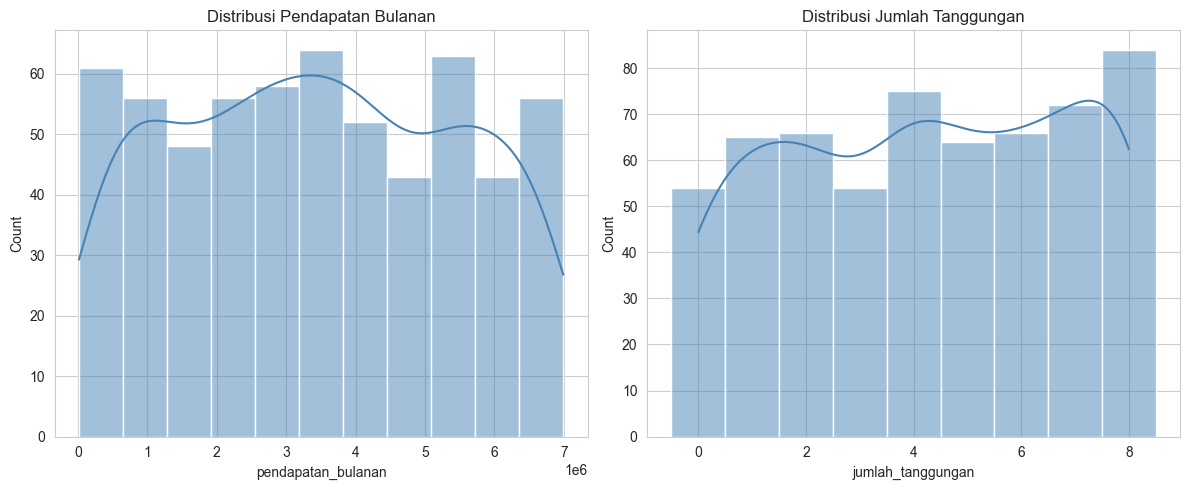

In [11]:
# Histogram untuk fitur numerik
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='pendapatan_bulanan', kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Pendapatan Bulanan')

sns.histplot(data=df, x='jumlah_tanggungan', kde=True, ax=axes[1], color='steelblue', discrete=True)
axes[1].set_title('Distribusi Jumlah Tanggungan')

plt.tight_layout()
plt.show()

### 4.3 Hubungan Fitur Numerik dengan Kategori Kelayakan

Boxplot untuk melihat pola pendapatan dan jumlah tanggungan antar kategori kelayakan — sesuai bobot MCDM, pendapatan (bobot 0.35) diharapkan jadi pembeda paling kuat.

C:\Users\shabrina\AppData\Local\Temp\ipykernel_48488\1354173127.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\shabrina\AppData\Local\Temp\ipykernel_48488\1354173127.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


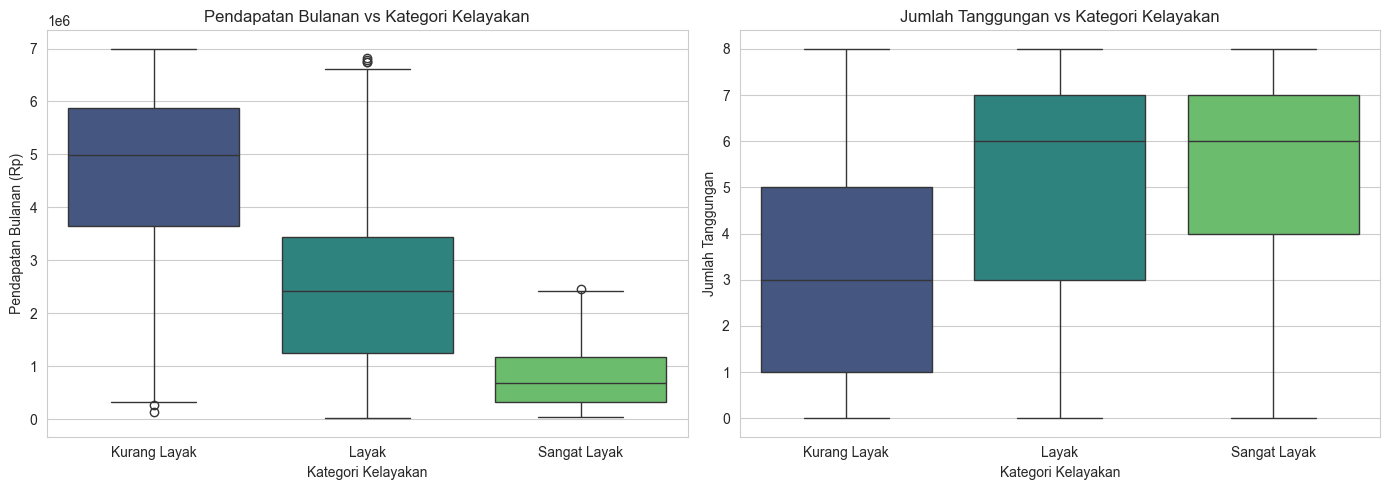

In [12]:
# Boxplot pendapatan_bulanan & jumlah_tanggungan per kategori kelayakan
urutan_kategori = ['Kurang Layak', 'Layak', 'Sangat Layak']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, x=kolom_target, y='pendapatan_bulanan',
    order=urutan_kategori, palette='viridis', ax=axes[0]
)
axes[0].set_title('Pendapatan Bulanan vs Kategori Kelayakan')
axes[0].set_xlabel('Kategori Kelayakan')
axes[0].set_ylabel('Pendapatan Bulanan (Rp)')

sns.boxplot(
    data=df, x=kolom_target, y='jumlah_tanggungan',
    order=urutan_kategori, palette='viridis', ax=axes[1]
)
axes[1].set_title('Jumlah Tanggungan vs Kategori Kelayakan')
axes[1].set_xlabel('Kategori Kelayakan')
axes[1].set_ylabel('Jumlah Tanggungan')

plt.tight_layout()
plt.show()

### 4.4 Sebaran Fitur Kategorikal & Ordinal

Melihat proporsi kategori kelayakan berdasarkan kondisi tempat tinggal, kepemilikan aset, dan indikator tambahan.

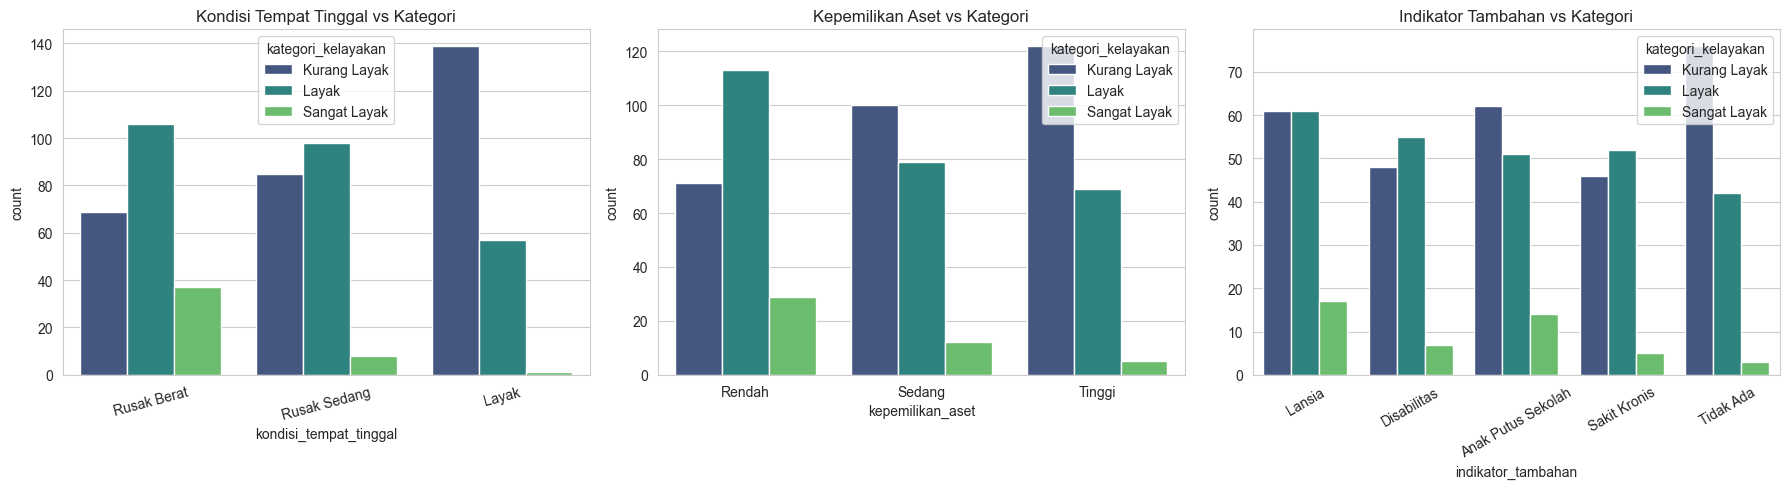

In [13]:
# Countplot untuk fitur kategorikal/ordinal terhadap target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='kondisi_tempat_tinggal', hue=kolom_target,
              order=['Rusak Berat', 'Rusak Sedang', 'Layak'],
              hue_order=urutan_kategori, palette='viridis', ax=axes[0])
axes[0].set_title('Kondisi Tempat Tinggal vs Kategori')
axes[0].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x='kepemilikan_aset', hue=kolom_target,
              order=['Rendah', 'Sedang', 'Tinggi'],
              hue_order=urutan_kategori, palette='viridis', ax=axes[1])
axes[1].set_title('Kepemilikan Aset vs Kategori')

sns.countplot(data=df, x='indikator_tambahan', hue=kolom_target,
              hue_order=urutan_kategori, palette='viridis', ax=axes[2])
axes[2].set_title('Indikator Tambahan vs Kategori')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 4.5 Korelasi Antar Fitur Numerik

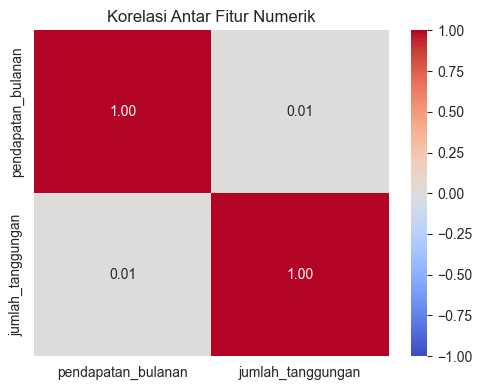

In [14]:
# Heatmap korelasi antar fitur numerik
plt.figure(figsize=(5, 4))
korelasi = df[fitur_numerik].corr()
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

## 5. Split Data (Train-Test)

Membagi data menjadi data latih (*train*) dan data uji (*test*) dengan proporsi 80:20 — sama dengan `test_size=0.2` di `train_and_save()` pada `ai_model.py`. Parameter `stratify` digunakan agar proporsi tiap kelas pada data train dan test tetap seimbang.

In [15]:
# Menyusun fitur (X) dan target (y) — urutan kolom mengikuti _encode_row() di ai_model.py:
# [pendapatan_bulanan, jumlah_tanggungan, kondisi_tempat_tinggal, kepemilikan_aset, indikator_tambahan]
fitur_final = ['pendapatan_bulanan', 'jumlah_tanggungan', 'kondisi_tempat_tinggal',
               'kepemilikan_aset', 'indikator_tambahan']

X = df_encoded[fitur_final]
y = df_encoded['kategori_kelayakan_encoded']

print('Jumlah fitur yang digunakan:', len(fitur_final))
print('Daftar fitur (urutan harus sama dengan _encode_row di ai_model.py):')
print(fitur_final)

Jumlah fitur yang digunakan: 5
Daftar fitur (urutan harus sama dengan _encode_row di ai_model.py):
['pendapatan_bulanan', 'jumlah_tanggungan', 'kondisi_tempat_tinggal', 'kepemilikan_aset', 'indikator_tambahan']


In [16]:
# Split data menjadi train (80%) dan test (20%), stratified seperti pada ai_model.py
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Jumlah data latih (train) : {X_train.shape[0]} baris')
print(f'Jumlah data uji (test)    : {X_test.shape[0]} baris')
print()
print('Proporsi kelas pada data train:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Proporsi kelas pada data test:')
print(y_test.value_counts(normalize=True).round(3))

Jumlah data latih (train) : 480 baris
Jumlah data uji (test)    : 120 baris

Proporsi kelas pada data train:
kategori_kelayakan_encoded
0    0.488
1    0.435
2    0.077
Name: proportion, dtype: float64

Proporsi kelas pada data test:
kategori_kelayakan_encoded
0    0.492
1    0.433
2    0.075
Name: proportion, dtype: float64


## 6. Training Model (Random Forest)

Melatih **Random Forest Classifier**. `n_estimators=120` dipilih agar **sama persis** dengan parameter di `train_and_save()` pada `ai_model.py`, sehingga model yang dihasilkan notebook ini setara dengan model yang akan dihasilkan backend saat dijalankan ulang.

Karena distribusi kelas tidak seimbang (lihat bagian EDA 4.1), `class_weight='balanced'` ditambahkan sebagai **peningkatan** dibanding kode asli `ai_model.py` (yang belum menggunakan parameter ini) — agar performa terhadap kelas minoritas (`Sangat Layak`) tidak terabaikan. Ini bisa menjadi catatan/usulan perbaikan ke `ai_model.py` jika hasilnya lebih baik.

In [17]:
# Inisialisasi model Random Forest
# n_estimators=120 disamakan dengan app/ai_model.py (train_and_save)
# class_weight='balanced' ditambahkan karena distribusi kelas tidak seimbang
model_rf = RandomForestClassifier(
    n_estimators=120,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Melatih model menggunakan data latih
model_rf.fit(X_train, y_train)

print('Model Random Forest berhasil dilatih.')

Model Random Forest berhasil dilatih.


## 7. Evaluasi Model

Mengukur performa model pada data uji (*test set*) menggunakan metrik accuracy, precision, recall, dan F1-score (rata-rata `weighted` karena kasus multi-kelas).

In [18]:
# Melakukan prediksi pada data uji
y_pred = model_rf.predict(X_test)

# Menghitung metrik evaluasi utama
akurasi = accuracy_score(y_test, y_pred)
presisi = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print('=== Hasil Evaluasi Model ===')
print(f'Accuracy  : {akurasi:.4f}')
print(f'Precision : {presisi:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')

=== Hasil Evaluasi Model ===
Accuracy  : 0.8917
Precision : 0.8913
Recall    : 0.8917
F1-Score  : 0.8911


In [19]:
# Classification report lengkap (precision, recall, f1-score per kelas)
nama_kelas = label_encoder.classes_

print('=== Classification Report (per kelas) ===')
print(classification_report(y_test, y_pred, target_names=nama_kelas))

=== Classification Report (per kelas) ===
              precision    recall  f1-score   support

Kurang Layak       0.90      0.93      0.92        59
       Layak       0.88      0.87      0.87        52
Sangat Layak       0.88      0.78      0.82         9

    accuracy                           0.89       120
   macro avg       0.89      0.86      0.87       120
weighted avg       0.89      0.89      0.89       120



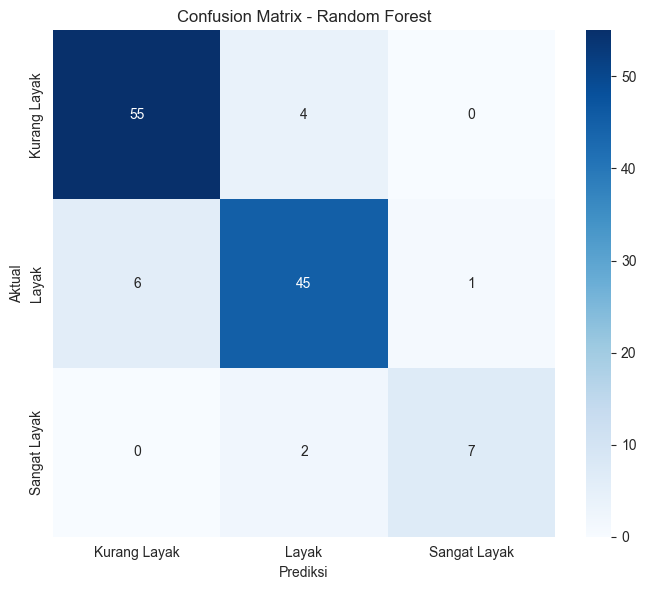

In [20]:
# Confusion matrix untuk melihat detail kesalahan prediksi tiap kelas
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=nama_kelas, yticklabels=nama_kelas
)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

> **Catatan interpretasi:** Karena label target berasal dari rumus MCDM yang deterministik (bukan data dunia nyata yang inheren "berisik"), akurasi model RF di sini secara wajar bisa **lebih tinggi** daripada model yang dilatih dari data lapangan asli. Ini diharapkan — tujuan RF di sini adalah mendekati fungsi MCDM, bukan menggantikannya. Skor MCDM tetap menjadi sumber kebenaran utama sistem.

## 8. Feature Importance (Explainability)

Membandingkan **feature importance hasil RF** dengan **bobot MCDM** yang didefinisikan manual di `ai_model.py` (`WEIGHTS`). Jika keduanya selaras, ini memperkuat validitas bahwa RF berhasil "belajar" pola yang sama dengan rumus MCDM — sekaligus jadi bentuk *sanity check* tambahan untuk laporan.

In [21]:
# Mengambil nilai feature importance dari model RF
feature_importance_df = pd.DataFrame({
    'fitur': fitur_final,
    'importance_rf': model_rf.feature_importances_
}).sort_values(by='importance_rf', ascending=False).reset_index(drop=True)

# Bobot MCDM asli dari app/ai_model.py, untuk perbandingan
bobot_mcdm = {
    'pendapatan_bulanan': 0.35,
    'jumlah_tanggungan': 0.20,
    'kondisi_tempat_tinggal': 0.20,
    'kepemilikan_aset': 0.15,
    'indikator_tambahan': 0.10
}
feature_importance_df['bobot_mcdm'] = feature_importance_df['fitur'].map(bobot_mcdm)

print(feature_importance_df)

                    fitur  importance_rf  bobot_mcdm
0      pendapatan_bulanan       0.522833        0.35
1  kondisi_tempat_tinggal       0.172346        0.20
2       jumlah_tanggungan       0.147818        0.20
3        kepemilikan_aset       0.091460        0.15
4      indikator_tambahan       0.065543        0.10


C:\Users\shabrina\AppData\Local\Temp\ipykernel_48488\3877049486.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='importance_rf', y='fitur', palette='viridis', ax=axes[0])
C:\Users\shabrina\AppData\Local\Temp\ipykernel_48488\3877049486.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='bobot_mcdm', y='fitur', palette='magma', ax=axes[1])


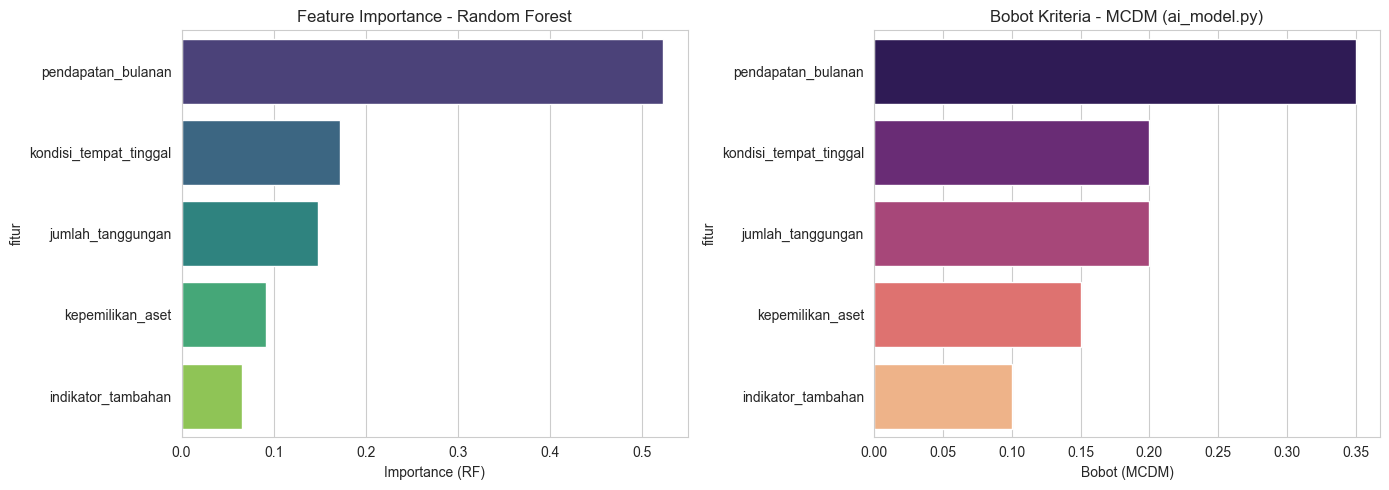

In [22]:
# Visualisasi perbandingan feature importance RF vs bobot MCDM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=feature_importance_df, x='importance_rf', y='fitur', palette='viridis', ax=axes[0])
axes[0].set_title('Feature Importance - Random Forest')
axes[0].set_xlabel('Importance (RF)')

sns.barplot(data=feature_importance_df, x='bobot_mcdm', y='fitur', palette='magma', ax=axes[1])
axes[1].set_title('Bobot Kriteria - MCDM (ai_model.py)')
axes[1].set_xlabel('Bobot (MCDM)')

plt.tight_layout()
plt.show()

**Interpretasi:** Pada sistem ini, *explainability* utama (UC-03) sebenarnya sudah disediakan secara langsung dan transparan oleh mekanisme MCDM melalui `faktor_penjelasan` di `compute_priority()` — setiap kontribusi fitur terhadap skor sudah dihitung eksplisit dan dapat ditampilkan ke pengguna tanpa perlu interpretasi tambahan. Feature importance dari Random Forest di sini berfungsi sebagai **validasi independen**: jika urutan kepentingan fitur versi RF konsisten dengan urutan bobot MCDM, ini menunjukkan bahwa pola yang dipelajari RF dari data sejalan dengan logika domain yang dirancang tim — memperkuat kredibilitas kedua pendekatan.

## 9. Menyimpan Model untuk Integrasi ke Web App

Model disimpan sebagai `model_rf.pkl` — **nama file yang sama** dengan `MODEL_PATH` pada `app/ai_model.py` (`data/model_rf.pkl`), sehingga dapat langsung menggantikan model yang dihasilkan `train_and_save()` tanpa perlu mengubah kode backend (`classify_with_model()`).

Encoder (`ordinal_encoder.pkl`, mapping `indikator_tambahan`, dan `label_encoder.pkl`) disimpan terpisah sebagai referensi/dokumentasi notebook — perlu diperhatikan bahwa `_encode_row()` di backend saat ini melakukan encoding manual memakai `.index()` pada tuple, sehingga **tidak butuh file encoder terpisah** untuk berjalan. File encoder dari notebook ini berguna jika ke depannya encoding ingin disatukan/divalidasi silang dengan notebook.

In [23]:
# Menyimpan model — nama file disamakan dengan MODEL_PATH di app/ai_model.py
joblib.dump(model_rf, 'model_rf.pkl')

# Menyimpan juga encoder & referensi kolom untuk dokumentasi / validasi silang dengan notebook
joblib.dump(ordinal_encoder, 'ordinal_encoder.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

import json
with open('feature_columns.json', 'w') as f:
    json.dump(fitur_final, f, indent=2)

print('Model dan komponen pendukung berhasil disimpan:')
print('  - model_rf.pkl            (model Random Forest, kompatibel dgn MODEL_PATH ai_model.py)')
print('  - ordinal_encoder.pkl     (referensi encoder fitur ordinal)')
print('  - label_encoder.pkl       (referensi encoder label target)')
print('  - feature_columns.json    (urutan kolom fitur, harus sama dgn _encode_row())')

Model dan komponen pendukung berhasil disimpan:
  - model_rf.pkl            (model Random Forest, kompatibel dgn MODEL_PATH ai_model.py)
  - ordinal_encoder.pkl     (referensi encoder fitur ordinal)
  - label_encoder.pkl       (referensi encoder label target)
  - feature_columns.json    (urutan kolom fitur, harus sama dgn _encode_row())


## Ringkasan

| Tahapan | Status |
|---|---|
| Data preprocessing (missing value, duplikat, encoding selaras `ai_model.py`) | Selesai |
| EDA (distribusi target, fitur numerik, korelasi, kategorikal) | Selesai |
| Split data (80:20, stratified, seed=42 sama dgn backend) | Selesai |
| Training Random Forest (n_estimators=120, sama dgn backend) | Selesai |
| Evaluasi (accuracy, precision, recall, F1-score) | Selesai |
| Feature importance vs bobot MCDM (explainability & validasi silang) | Selesai |
| Model `model_rf.pkl` siap menggantikan/melengkapi hasil `train_and_save()` | Selesai |

**Catatan integrasi ke `app/ai_model.py`:**
- File `model_rf.pkl` hasil notebook ini bisa langsung dipakai backend (taruh di `data/model_rf.pkl`), karena urutan fitur dan encoding numeriknya **identik** dengan `_encode_row()`.
- Mesin keputusan utama sistem **tetap MCDM** (`compute_priority()`); RF dari notebook ini berfungsi sebagai cross-check (`classify_with_model()`), sesuai desain awal di `ai_model.py`.
- Jika tim ingin RF berkontribusi lebih dari sekadar cross-check (misalnya ditampilkan sebagai metrik tambahan di halaman hasil), hasil evaluasi pada notebook ini (accuracy, precision, recall, F1, feature importance) bisa langsung dipakai sebagai bahan laporan/justifikasi di DPPL.